# MPSlib: Getting started with MPSlib/scikit-mps in Python

This is a small example for getting started with MPSlib through a Jupyter notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mpslib as mps

## Setup MPSlib

First, initialize an instance of the `mpslib` object.

In [3]:
# Initialize MPSlib using the default algorithm and settings
O = mps.mpslib()

# Initialize MPSlib using the mps_snesim_tree algorithm and a simulation grid of size [80, 70, 1]
O = mps.mpslib(method='mps_snesim_tree', simulation_grid_size=[80, 70, 1])

# Specific parameters can be passed directly when calling mps.mpslib (as above),
# or set by updating the O.par structure as shown below:
O.par['debug_level'] = -1
O.par['n_cond'] = 25
O.par['n_real'] = 16
O.par['n_threads'] = 5
O.par['do_entropy'] = 1
O.par['simulation_grid_size'] = np.array([80, 50, 1])

Using mps_genesim installed in /mnt/d/PROGRAMMING/mpslib (scikit-mps in /mnt/d/PROGRAMMING/mpslib/scikit-mps/mpslib/mpslib.py)
Using mps_snesim_tree installed in /mnt/d/PROGRAMMING/mpslib (scikit-mps in /mnt/d/PROGRAMMING/mpslib/scikit-mps/mpslib/mpslib.py)


All adjustable parameters for the chosen MPSlib algorithm:

In [4]:
O.par

{'n_real': 16,
 'rseed': 1,
 'n_max_cpdf_count': 1,
 'out_folder': '.',
 'ti_fnam': 'ti.dat',
 'simulation_grid_size': array([80, 50,  1]),
 'origin': array([0., 0., 0.]),
 'grid_cell_size': array([1, 1, 1]),
 'mask_fnam': 'mask.dat',
 'hard_data_fnam': 'hard.dat',
 'shuffle_simulation_grid': 2,
 'entropyfactor_simulation_grid': 4,
 'shuffle_ti_grid': 1,
 'hard_data_search_radius': 1,
 'soft_data_categories': array([0, 1]),
 'soft_data_fnam': 'soft.dat',
 'n_threads': 5,
 'debug_level': -1,
 'do_estimation': 0,
 'do_entropy': 1,
 'template_size': array([8, 7, 1]),
 'n_multiple_grids': 3,
 'n_min_node_count': 0,
 'n_cond': 25}

## Choose training image

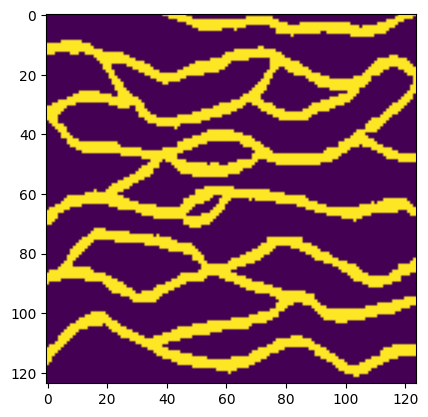

In [5]:
TI, TI_filename = mps.trainingimages.strebelle(di=2, coarse3d=1)
#TI, TI_filename = mps.trainingimages.rot90()
O.par['ti_fnam'] = TI_filename
plt.imshow(TI[:, :, 0].T)

## Run MPSlib

The chosen MPSlib algorithm is run using a single thread by executing

    O.run()

and using multiple threads by executing

    O.run_parallel()

In [6]:
#O.run()
O.run_parallel()

parallel: Using 4 of max 103 threads


## Plot some realizations using matplotlib

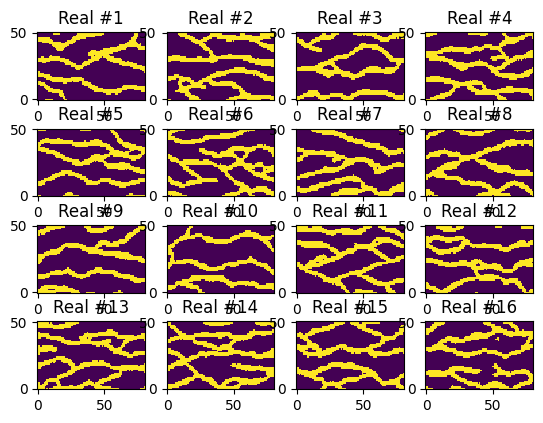

In [7]:
O.plot_reals()